<a href="https://colab.research.google.com/github/preshitgupta618-cell/ML-Basics-Linear-Regression-Assignment/blob/main/ML_Basics_%26_Linear_Regression_(Practical_Questions).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


# Q6: Load Dataset and Basic Exploration

df = pd.read_csv("/content/BostonHousing.csv")

print(df.head())

print(df.info())

print(df.describe())

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float6

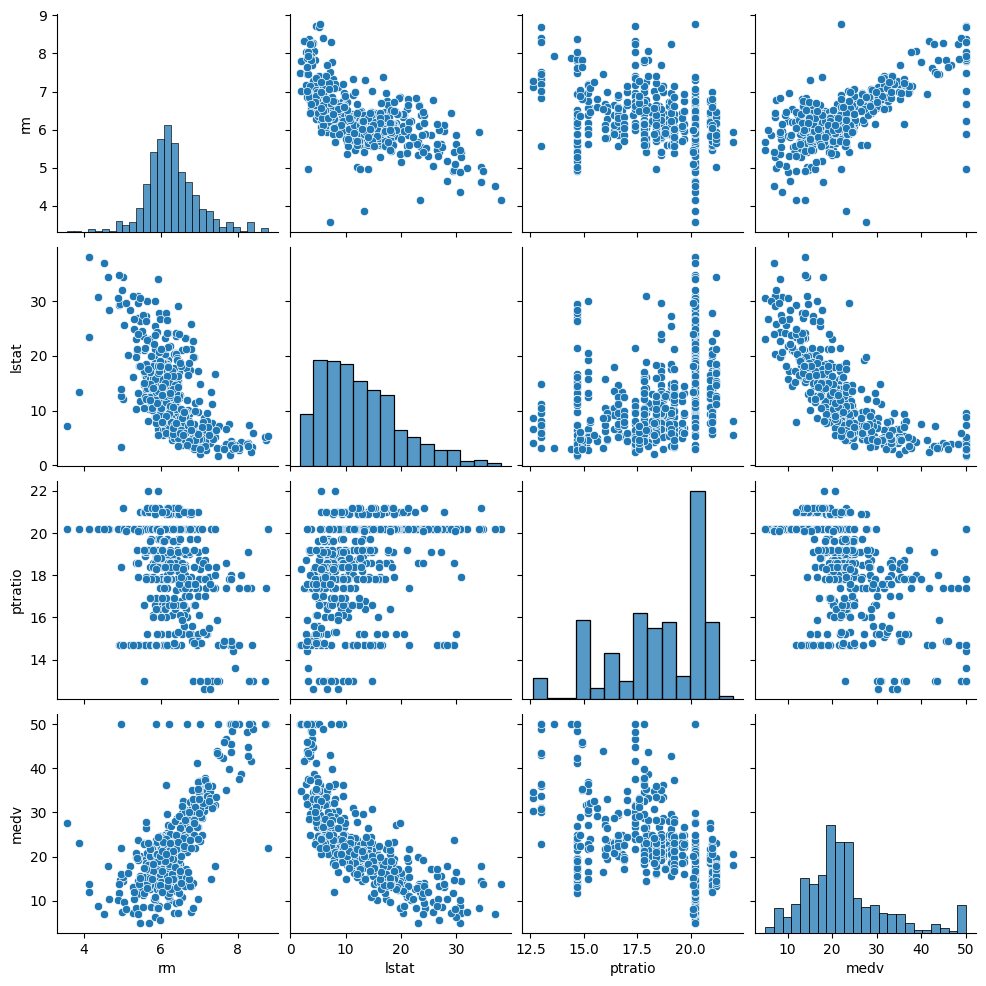

In [5]:
#Q7. Perform Exploratory Data Analysis:

#Create pairplot

sns.pairplot(df[['rm', 'lstat', 'ptratio', 'medv']])
plt.savefig('pairplot.png')

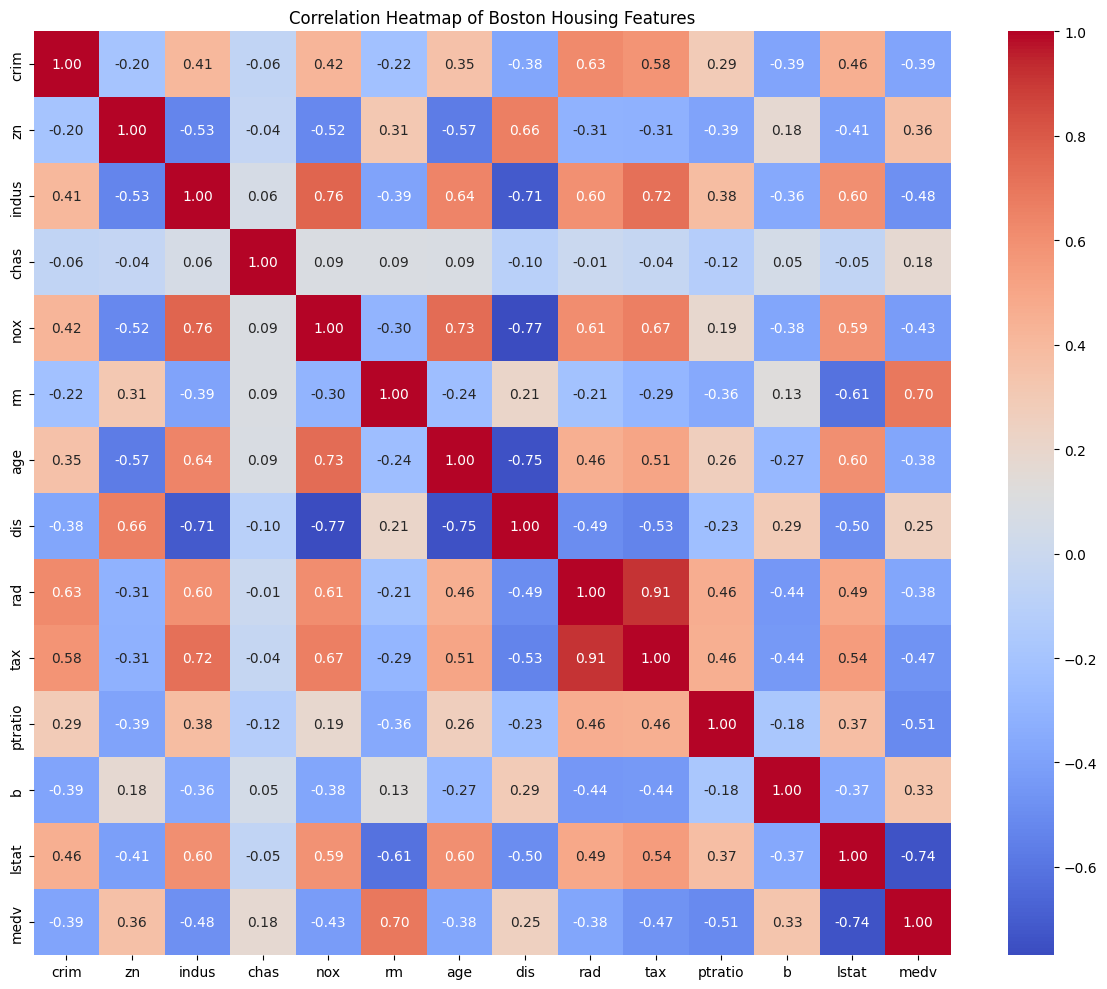

In [ ]:
#Create correlation heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Boston Housing Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

In [6]:
#Identify which features are highly correlated with house price (medv)

correlations = df.corr()['medv'].sort_values(ascending=False)
print("\nCorrelations with medv:")
print(correlations)


Correlations with medv:
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


In [7]:
# Q8: Select Variables

X = df.drop('medv', axis=1)
y = df['medv']

In [9]:
# Q9: Split Dataset (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Q10: Train Model and Predict

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluation Metrics
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, predictions)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2: {adj_r2}")

MAE: 3.189091965887837
MSE: 24.291119474973478
RMSE: 4.928602182665332
R2 Score: 0.6687594935356326
Adjusted R2: 0.619826236898851
